# N1 · DiT 条件生成 (Conditional Generation)

> 配套 13.3-L1 · 用 transformer 去噪器 (DiT) 在 4 类高斯团上训练, 指定类别生成对应的团。
> 看 transformer 怎么做条件扩散 (你的本行)。

In [1]:
import sys
from pathlib import Path
SRC = Path.cwd().parent / "src"
sys.path.insert(0, str(SRC))
import numpy as np, torch
import dit
print('dit 就绪')

dit 就绪


## 1. 4 类高斯团 (四角, 每团一类). 条件扩散要按类生成

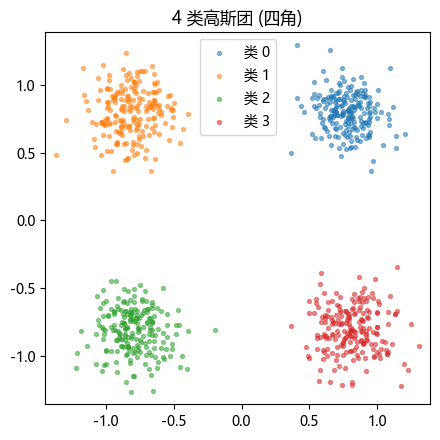

In [2]:
import matplotlib, matplotlib.pyplot as plt
matplotlib.rcParams['axes.unicode_minus']=False
for f in ['Microsoft YaHei','SimHei','DejaVu Sans']:
    try: matplotlib.rcParams['font.sans-serif']=[f]; break
    except Exception: pass
x, y = dit.make_class_blobs(n_per=200, seed=1)
fig, ax = plt.subplots(figsize=(4.5,4.5))
for c in range(4):
    m = y==c; ax.scatter(x[m,0], x[m,1], s=8, alpha=0.5, label=f'类 {c}')
ax.legend(); ax.set_title('4 类高斯团 (四角)'); ax.axis('equal'); plt.tight_layout(); plt.show()

## 2. 训练 DiT (transformer 去噪 + 时间/类别条件, L1)

In [3]:
torch.manual_seed(0)
model = dit.build_dit()
losses, sched = dit.train_dit(model, x, y, epochs=700)
print(f"DiT 训练: loss {losses[0]:.3f} → {losses[-1]:.3f}")

DiT 训练: loss 1.631 → 0.148


## 3. 条件生成: 指定每个类别, 生成对应的团 (guidance=2)

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


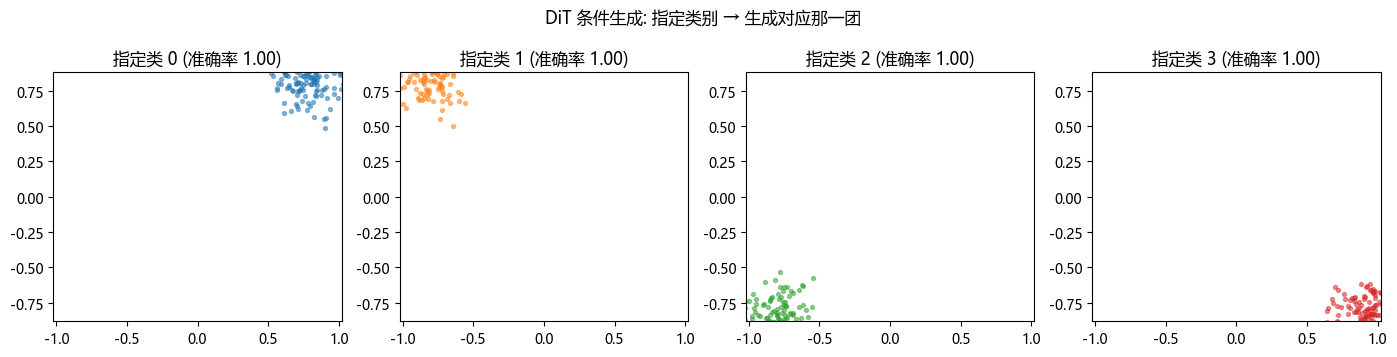

→ transformer 去噪器按类别条件生成对应的团 (条件扩散, L1)。


In [4]:
import matplotlib, matplotlib.pyplot as plt
matplotlib.rcParams['axes.unicode_minus']=False
for f in ['Microsoft YaHei','SimHei','DejaVu Sans']:
    try: matplotlib.rcParams['font.sans-serif']=[f]; break
    except Exception: pass
fig, axes = plt.subplots(1, 4, figsize=(14,3.6))
for c, ax in enumerate(axes):
    s = dit.sample(model, sched, cls=c, n=150, guidance=2.0, seed=3)
    ax.scatter(s[:,0], s[:,1], s=8, alpha=0.5, color=f'C{c}')
    acc = dit.class_accuracy(s, c)
    ax.set_title(f'指定类 {c} (准确率 {acc:.2f})'); ax.axis('equal'); ax.set_xlim(-1.2,1.2); ax.set_ylim(-1.2,1.2)
plt.suptitle('DiT 条件生成: 指定类别 → 生成对应那一团'); plt.tight_layout(); plt.show()
print("→ transformer 去噪器按类别条件生成对应的团 (条件扩散, L1)。")

## 4. 反思
你用 transformer (DiT) 做了条件扩散生成。带走:
- DiT = ViT 结构 + 扩散目标; 你的 transformer 知识直接迁移到生成式媒体。
- 条件 (时间 + 类别) 当 token 注入, 让去噪知道「当前噪声水平 + 要生成什么」。
下一步 N2: guidance scale 怎么控制「生成多贴近指定类」(CFG, L3)。